# Labor Market Structure in Argentina

This notebook loads the ENES microdata, inspects the survey structure, and computes a compact set of labor-market indicators: participation, employment, unemployment, inactivity, informality proxies, and breakdowns by demographic and occupational dimensions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("../data/raw/base_enespersonas.csv")
METADATA_PATH = Path("../data/raw/metadata_base_enespersonas.csv")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print(f"Data path exists: {DATA_PATH.exists()}")
print(f"Metadata path exists: {METADATA_PATH.exists()}")

Data path exists: True
Metadata path exists: True


## 1. Load Libraries and Data

The notebook uses the raw ENES person-level microdata because it contains the labor-status and job-quality variables needed for the indicators below.

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep=";", low_memory=False)
metadata = pd.read_csv(METADATA_PATH)

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns):,}")
display(df_raw.head())

Rows: 27,615
Columns: 157


,nocues,nhog,miembro,f_calib3,region,aglo,t_aglo,estrato_U,cod_U,v108,v109,v110,v111,v112,v113,v114,v115,v116,c_hogar,t_hogar,v117,v118a,v118b,v118c,v119,v120,v121,v122,v123,v124,v125,nivel_ed,v126,v127,v128,v129,v130,v131,v132,v133,v134a,v134b,v135,v136,v137,v138,v139,v140,v141,v142,v143,v144,v145,v146,v147a,v147b,v147c,v148,v149a,v149b_pcia,...,v182caes,v183ciuo,v183cno,v188,v189,v190,v191,v192,v193,v194,v195,v196,v197,v198,v199,cat_ocup,egp11,CSO,v200,v201a,v201b,v201c,v201d,v202,v203a,v203b,v203c,v203d,v203e,v203f,v204,v205,v206a,v206b,v207,v208,v209,v210a,v210b,v211,v212,v213a,v213b,v213bi,v214a,v214b,v214bi,ITLi,ITLi_d,v215a,v215b,v215bi,v216a,v216b,v216bi,v217a,v217b,v217bi,ITI,ITI_d
0,1.0,1.0,1.0,778.0,3.0,6.0,4.0,164.0,682.0,56.0,1.0,2.0,1.0,NaN,NaN,1.0,2.0,2.0,6.0,5.0,1.0,1.0,NaN,NaN,3.0,2.0,7.0,2.0,3.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,6.0,2.0,NaN,NaN,NaN,1.0,1.0,2.0,4.0,0.0,NaN,NaN,NaN,6.0,NaN,NaN,3.0,1.0,NaN,...,8401.0,3120.0,72203.0,1.0,5.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,1.0,4.0,3.0,2.0,3.0,NaN,NaN,1.0,1.0,2.0,3.0,4.0,5.0,6.0,1.0,1.0,16:00:00,NaN,2.0,3.0,1.0,1.0,3.0,00:15:00,8.0,1.0,4500.0,4500.0,0.0,NaN,0.0,4500.0,5.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,4500.0,6.0
1,1.0,1.0,2.0,778.0,3.0,6.0,4.0,164.0,682.0,51.0,2.0,10.0,2.0,NaN,NaN,1.0,1.0,2.0,6.0,5.0,1.0,1.0,NaN,NaN,3.0,2.0,6.0,1.0,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,6.0,1.0,5.0,1.0,00:15:00,1.0,1.0,2.0,4.0,0.0,2.0,2.0,NaN,6.0,NaN,NaN,3.0,2.0,NaN,...,8501.0,2330.0,41312.0,1.0,5.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,2.0,4.0,3.0,2.0,NaN,NaN,NaN,1.0,1.0,2.0,3.0,4.0,5.0,6.0,2.0,1.0,06:00:00,NaN,2.0,3.0,1.0,1.0,3.0,00:15:00,8.0,1.0,4000.0,4000.0,0.0,NaN,0.0,4000.0,4.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,4000.0,5.0
2,1.0,1.0,3.0,778.0,3.0,6.0,4.0,164.0,682.0,31.0,2.0,4.0,3.0,2.0,1.0,1.0,4.0,2.0,6.0,5.0,1.0,1.0,NaN,NaN,3.0,2.0,7.0,2.0,2.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,2.0,NaN,NaN,NaN,2.0,2.0,1.0,4.0,NaN,1.0,2.0,NaN,6.0,NaN,NaN,3.0,1.0,NaN,...,4804.0,5223.0,30314.0,2.0,2.0,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,4.0,6.0,3.0,9.0,NaN,NaN,NaN,3.0,9.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN
3,1.0,1.0,4.0,778.0,3.0,6.0,4.0,164.0,682.0,31.0,1.0,2.0,5.0,NaN,NaN,1.0,3.0,2.0,6.0,5.0,1.0,1.0,NaN,NaN,3.0,2.0,4.0,1.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,2.0,NaN,NaN,NaN,2.0,2.0,1.0,4.0,NaN,NaN,NaN,NaN,6.0,NaN,NaN,3.0,1.0,NaN,...,800.0,8111.0,70313.0,2.0,6.0,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,8.0,8.0,1.0,2.0,3.0,NaN,NaN,3.0,2.0,3.0,4.0,5.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN
4,1.0,1.0,5.0,778.0,3.0,6.0,4.0,164.0,682.0,7.0,2.0,8.0,7.0,3.0,4.0,NaN,NaN,1.0,6.0,5.0,1.0,1.0,NaN,NaN,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,2.0,NaN,NaN,NaN,1.0,1.0,1.0,4.0,NaN,NaN,NaN,3.0,6.0,NaN,NaN,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN


## 2. Inspect Dataset Structure

Review the raw column names, data types, missingness, and a small descriptive summary before deriving indicators.

In [3]:
display(pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_share": df_raw.isna().mean().round(3),
}).sort_values("missing_share", ascending=False).head(25))

print("Descriptive statistics for numeric columns:")
display(df_raw.select_dtypes(include="number").describe().T.head(20))

print("Metadata sample:")
display(metadata.head())

,dtype,missing,missing_share
v147c,float64,27613,1.000
v150b_pais,float64,27601,0.999
v147b,float64,27557,0.998
v133,float64,27524,0.997
v118b,float64,27515,0.996
v129,float64,27400,0.992
v131,float64,27311,0.989
v132,float64,27311,0.989
v170,float64,27246,0.987
v166,float64,27207,0.985


Descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
nocues,27610.0,4065.264976,2396.581322,1.0,1965.00,4029.0,6140.75,8308.0
nhog,27610.0,1.031981,0.199492,1.0,1.00,1.0,1.00,5.0
miembro,27610.0,2.673452,1.694321,1.0,1.00,2.0,4.00,17.0
f_calib3,27610.0,1356.793589,1516.333687,8.0,540.25,895.0,1567.00,27258.0
region,27610.0,4.568453,2.197641,1.0,3.00,5.0,7.00,8.0
aglo,27610.0,4.841398,1.742802,1.0,4.00,6.0,6.00,6.0
t_aglo,27610.0,1.863021,1.071867,1.0,1.00,1.0,3.00,4.0
estrato_U,27610.0,145.362731,75.148411,1.0,83.00,145.0,215.00,268.0
cod_U,27610.0,540.690040,258.635214,1.0,335.00,559.0,760.00,984.0
v108,27610.0,33.285150,22.255289,0.0,15.00,30.0,50.00,99.0


Metadata sample:


,Column Title,Data Type,Description
0,nocues,Integer,Housing Identification Code
1,nhog,Integer,Household Identification Code
2,miembro,Integer,Member Identification Code
3,f_calib3,Integer,Calibration Factor
4,region,Integer,Region


## 3. Clean and Standardize Variables

Rename the most relevant variables, convert codes into readable labels, and build derived labor-status fields.

In [4]:
df = df_raw.copy()

rename_map = {
    "v108": "age",
    "v109": "sex_code",
    "nivel_ed": "education_level",
    "v171": "worked_last_week",
    "v172": "odd_jobs_last_week",
    "v175": "available_to_work",
    "v176": "searched_work_30d",
    "v177": "search_duration",
    "v178": "reason_not_searching",
    "v180": "ever_worked_for_pay",
    "v182caes": "caes_code",
    "v183ciuo": "ciuo_code",
    "v188": "activity_sector",
    "v190": "job_tenure_raw",
    "v191": "employment_relationship",
    "v197": "afip_registration",
    "v199": "job_stability",
    "v206a": "hours_main_job_raw",
    "v207": "wants_more_hours",
    "v208": "can_work_more_hours",
    "v209": "workplace_location",
    "ITLi": "labor_income",
    "ITI": "total_income",
    "f_calib3": "weight",
}

df = df.rename(columns=rename_map)

def parse_hours(series: pd.Series) -> pd.Series:
    parsed = pd.to_timedelta(series.astype(str), errors="coerce")
    return parsed.dt.total_seconds() / 3600.0

for source, target in [("hours_main_job_raw", "hours_main_job")]:
    if source in df.columns:
        df[target] = parse_hours(df[source])

sex_map = {1: "Varón", 2: "Mujer"}
df["sex"] = df["sex_code"].map(sex_map).fillna("No informado")

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["education_level"] = pd.to_numeric(df["education_level"], errors="coerce")
df["weight"] = pd.to_numeric(df["weight"], errors="coerce").fillna(0.0)

age_bins = [14, 24, 34, 44, 54, 64, 120]
age_labels = ["15-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=True)
df["education_group"] = pd.cut(
    df["education_level"],
    bins=[-1, 2, 4, 6, 8, 20],
    labels=["Primary or less", "Lower secondary", "Upper secondary", "Tertiary", "University+"],
)

def as_binary(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").eq(1)

df["employed"] = as_binary(df.get("worked_last_week", pd.Series(index=df.index))) | as_binary(
    df.get("odd_jobs_last_week", pd.Series(index=df.index))
)
df["unemployed"] = (~df["employed"]) & as_binary(df.get("available_to_work", pd.Series(index=df.index))) & as_binary(
    df.get("searched_work_30d", pd.Series(index=df.index))
)
df["inactive"] = (~df["employed"]) & (~df["unemployed"])
df["labor_force"] = df["employed"] | df["unemployed"]
df["employment_condition"] = np.select(
    [df["employed"], df["unemployed"]],
    ["Employed", "Unemployed"],
    default="Inactive",
)

print("Standardized columns created:")
display(df[["age", "sex", "education_level", "age_group", "education_group", "employment_condition"]].head())

Standardized columns created:


,age,sex,education_level,age_group,education_group,employment_condition
0,56.0,Varón,8.0,55-64,Tertiary,Employed
1,51.0,Mujer,7.0,45-54,Tertiary,Employed
2,31.0,Mujer,8.0,25-34,Tertiary,Inactive
3,31.0,Varón,5.0,25-34,Upper secondary,Unemployed
4,7.0,Mujer,2.0,NaN,Primary or less,Inactive


## 4. Compute Core Labor Market Indicators

Calculate weighted participation, employment, unemployment, and inactivity rates using the calibration factor as survey weight.

In [5]:
analysis_df = df[df["age"].ge(15)].copy()
analysis_df = analysis_df[analysis_df["weight"].gt(0)]


def weighted_mean(series: pd.Series, weights: pd.Series) -> float:
    valid = series.notna() & weights.notna() & weights.gt(0)
    if not valid.any():
        return float("nan")
    return float(np.average(series.loc[valid].astype(float), weights=weights.loc[valid].astype(float)))


indicator_rows = {
    "participation_rate": weighted_mean(analysis_df["labor_force"], analysis_df["weight"]),
    "employment_rate": weighted_mean(analysis_df["employed"], analysis_df["weight"]),
    "unemployment_rate": weighted_mean(analysis_df["unemployed"], analysis_df["weight"]),
    "inactivity_rate": weighted_mean(analysis_df["inactive"], analysis_df["weight"]),
}

core_indicators = pd.DataFrame(
    {"indicator": list(indicator_rows.keys()), "value": list(indicator_rows.values())}
)
core_indicators["value_pct"] = (100 * core_indicators["value"]).round(2)
display(core_indicators)

print("Weighted sample size:", f"{analysis_df['weight'].sum():,.0f}")

,indicator,value,value_pct
0,participation_rate,0.620216,62.02
1,employment_rate,0.586332,58.63
2,unemployment_rate,0.033884,3.39
3,inactivity_rate,0.379784,37.98


Weighted sample size: 28,129,849


## 5. Analyze Employment Status

Compare the distribution of employment conditions across the weighted sample.

In [6]:
status_summary = (
    analysis_df.groupby("employment_condition", dropna=False)
    .agg(weighted_count=("weight", "sum"))
    .reset_index()
)
status_summary["share_pct"] = (100 * status_summary["weighted_count"] / status_summary["weighted_count"].sum()).round(2)
display(status_summary.sort_values("weighted_count", ascending=False))

status_by_sex = pd.pivot_table(
    analysis_df,
    index="sex",
    columns="employment_condition",
    values="weight",
    aggfunc="sum",
    fill_value=0,
)
status_by_sex = status_by_sex.div(status_by_sex.sum(axis=1), axis=0).mul(100).round(2)
display(status_by_sex)

,employment_condition,weighted_count,share_pct
0,Employed,16493425.0,58.63
1,Inactive,10683268.0,37.98
2,Unemployed,953156.0,3.39


employment_condition,Employed,Inactive,Unemployed
sex,,,
Mujer,46.71,49.15,4.15
No informado,51.39,24.37,24.24
Varón,72.01,25.46,2.53


## 6. Analyze Informality and Job Quality

Inspect proxies for labor informality, job stability, hours worked, and income distributions.

In [7]:
for col in ["afip_registration", "employment_relationship", "job_stability", "hours_main_job", "labor_income", "total_income", "wants_more_hours", "can_work_more_hours"]:
    if col in analysis_df.columns:
        print(f"\n{col} value counts:")
        display(analysis_df[col].value_counts(dropna=False).head(10))

# Heuristic informality proxy: employed people without the two strongest formalization signals.
registered_with_tax_authority = analysis_df.get("afip_registration", pd.Series(index=analysis_df.index)).astype("float").eq(1)
pension_contributor = analysis_df.get("employment_relationship", pd.Series(index=analysis_df.index)).astype("float").isin([1, 2])
analysis_df["informal_proxy"] = analysis_df["employed"] & ~(registered_with_tax_authority | pension_contributor)

job_quality_summary = pd.DataFrame({
    "informality_proxy_rate": [weighted_mean(analysis_df["informal_proxy"], analysis_df["weight"])],
    "avg_hours_main_job": [weighted_mean(analysis_df["hours_main_job"], analysis_df["weight"])],
    "avg_labor_income": [weighted_mean(analysis_df["labor_income"], analysis_df["weight"])],
    "avg_total_income": [weighted_mean(analysis_df["total_income"], analysis_df["weight"])],
})
job_quality_summary = job_quality_summary.T.reset_index()
job_quality_summary.columns = ["indicator", "value"]
job_quality_summary["value_pct_or_amount"] = job_quality_summary["value"].astype(float)
display(job_quality_summary)


afip_registration value counts:


afip_registration
NaN    17159
1.0     2039
3.0     1406
2.0      245
Name: count, dtype: int64


employment_relationship value counts:


employment_relationship
3.0    11997
NaN     4782
1.0     3597
2.0      473
Name: count, dtype: int64


job_stability value counts:


...


wants_more_hours value counts:


wants_more_hours
NaN    9489
2.0    8037
1.0    3323
Name: count, dtype: int64


can_work_more_hours value counts:


can_work_more_hours
NaN    9454
3.0    6033
1.0    4837
2.0     525
Name: count, dtype: int64

,indicator,value,value_pct_or_amount
0,informality_proxy_rate,0.414636,0.414636
1,avg_hours_main_job,10.895180,10.895180
2,avg_labor_income,7060.191755,7060.191755
3,avg_total_income,6736.864920,6736.864920


## 7. Break Down Results by Demographics

Compare the main labor indicators by gender, age group, and education group.

In [8]:
def weighted_group_summary(frame: pd.DataFrame, group_col: str, columns: list[str]) -> pd.DataFrame:
    rows = []
    for group_value, group_frame in frame.groupby(group_col, dropna=False):
        row = {group_col: group_value}
        for column in columns:
            if column in group_frame.columns:
                row[column] = weighted_mean(group_frame[column], group_frame["weight"])
        rows.append(row)
    return pd.DataFrame(rows)


demographic_summary = weighted_group_summary(
    analysis_df,
    "sex",
    ["employed", "unemployed", "informal_proxy", "hours_main_job", "labor_income"],
)
display(demographic_summary.sort_values("labor_income", ascending=False))

age_summary = weighted_group_summary(
    analysis_df,
    "age_group",
    ["employed", "unemployed", "informal_proxy", "hours_main_job", "labor_income"],
)
display(age_summary.sort_values("age_group"))

education_summary = weighted_group_summary(
    analysis_df,
    "education_group",
    ["employed", "unemployed", "informal_proxy", "hours_main_job", "labor_income"],
)
display(education_summary.sort_values("education_group"))

,sex,employed,unemployed,informal_proxy,hours_main_job,labor_income
2,Varón,0.720079,0.025304,0.496575,10.864941,7933.939860
0,Mujer,0.467054,0.041481,0.341605,10.938616,5886.709342
1,No informado,0.513923,0.242417,0.210343,5.036872,2173.134978


/tmp/ipykernel_8508/691328733.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, group_frame in frame.groupby(group_col, dropna=False):


,age_group,employed,unemployed,informal_proxy,hours_main_job,labor_income
0,15-24,0.367602,0.071147,0.285222,10.686515,4710.459163
1,25-34,0.748852,0.046637,0.584139,10.739979,6947.306303
2,35-44,0.815200,0.023639,0.589003,11.052186,7424.017715
3,45-54,0.793110,0.014516,0.514970,10.995719,7696.606373
4,55-64,0.638980,0.012274,0.403312,11.013441,8040.750095
5,65+,0.187430,0.005609,0.089595,10.741465,6894.743708


/tmp/ipykernel_8508/691328733.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, group_frame in frame.groupby(group_col, dropna=False):


,education_group,employed,unemployed,informal_proxy,hours_main_job,labor_income
1,Lower secondary,0.508289,0.033053,0.341083,10.695025,5419.886537
0,Primary or less,0.450890,0.024819,0.303404,10.337630,4783.744597
3,Tertiary,0.658930,0.030003,0.501683,11.074364,8349.607072
4,University+,0.778826,0.014675,0.553934,11.699898,11479.218301
2,Upper secondary,0.653413,0.046637,0.473307,10.868783,7075.035234
5,NaN,0.286200,0.000000,0.286200,NaN,NaN


## 8. Break Down Results by Sector and Occupation

Inspect employment and income patterns by activity sector, occupation code, and workplace location.

In [9]:
sector_summary = (
    analysis_df.groupby("caes_code", dropna=False)
    .apply(lambda g: pd.Series({
        "weighted_employed": np.average(g["employed"].astype(float), weights=g["weight"]),
        "weighted_income": weighted_mean(g["labor_income"], g["weight"]),
        "weighted_count": g["weight"].sum(),
    }))
    .reset_index()
    .sort_values("weighted_count", ascending=False)
)
display(sector_summary.head(15))

occupation_summary = (
    analysis_df.groupby("ciuo_code", dropna=False)
    .apply(lambda g: pd.Series({
        "weighted_employed": np.average(g["employed"].astype(float), weights=g["weight"]),
        "weighted_income": weighted_mean(g["labor_income"], g["weight"]),
        "weighted_count": g["weight"].sum(),
    }))
    .reset_index()
    .sort_values("weighted_count", ascending=False)
)
display(occupation_summary.head(15))

if "workplace_location" in analysis_df.columns:
    workplace_summary = analysis_df["workplace_location"].value_counts(dropna=False).to_frame("count")
    workplace_summary["share_pct"] = (100 * workplace_summary["count"] / workplace_summary["count"].sum()).round(2)
    display(workplace_summary.head(10))

/tmp/ipykernel_8508/2328249002.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,caes_code,weighted_employed,weighted_income,weighted_count
143,NaN,0.000885,NaN,6097081.0
141,9700.0,0.603673,2995.560143,2311324.0
61,4000.0,0.859990,5901.212821,2194342.0
121,8501.0,0.699860,8454.835093,1774137.0
123,8600.0,0.780729,8953.990928,923898.0
118,8401.0,0.773302,9448.438527,856325.0
74,4808.0,0.800918,5558.093395,804949.0
142,9999.0,0.694830,8001.925759,767994.0
90,5601.0,0.730242,5673.190749,760433.0
81,4903.0,0.830804,8635.573043,454201.0


/tmp/ipykernel_8508/2328249002.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,ciuo_code,weighted_employed,weighted_income,weighted_count
450,NaN,0.000885,NaN,6097081.0
412,9111.0,0.592312,2936.985546,1599660.0
258,5223.0,0.696161,5108.468515,1247081.0
295,7112.0,0.853092,5412.809647,1017961.0
256,5221.0,0.836187,6139.949142,873360.0
207,4110.0,0.738570,8791.852019,802269.0
449,9999.0,0.680481,6929.511611,487230.0
413,9112.0,0.678829,5212.682484,469744.0
269,5311.0,0.577421,2412.676115,433360.0
402,8322.0,0.921239,7459.220100,400465.0


,count,share_pct
workplace_location,,
NaN,9454,45.35
1.0,9263,44.43
2.0,1768,8.48
3.0,355,1.70
4.0,9,0.04


## 9. Create Visualizations and Summary Tables

Build a few compact charts that summarize the labor market structure at a glance.

/tmp/ipykernel_8508/2468643904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_summary, x="employment_condition", y="share_pct", ax=axes[0, 1], palette="deep")


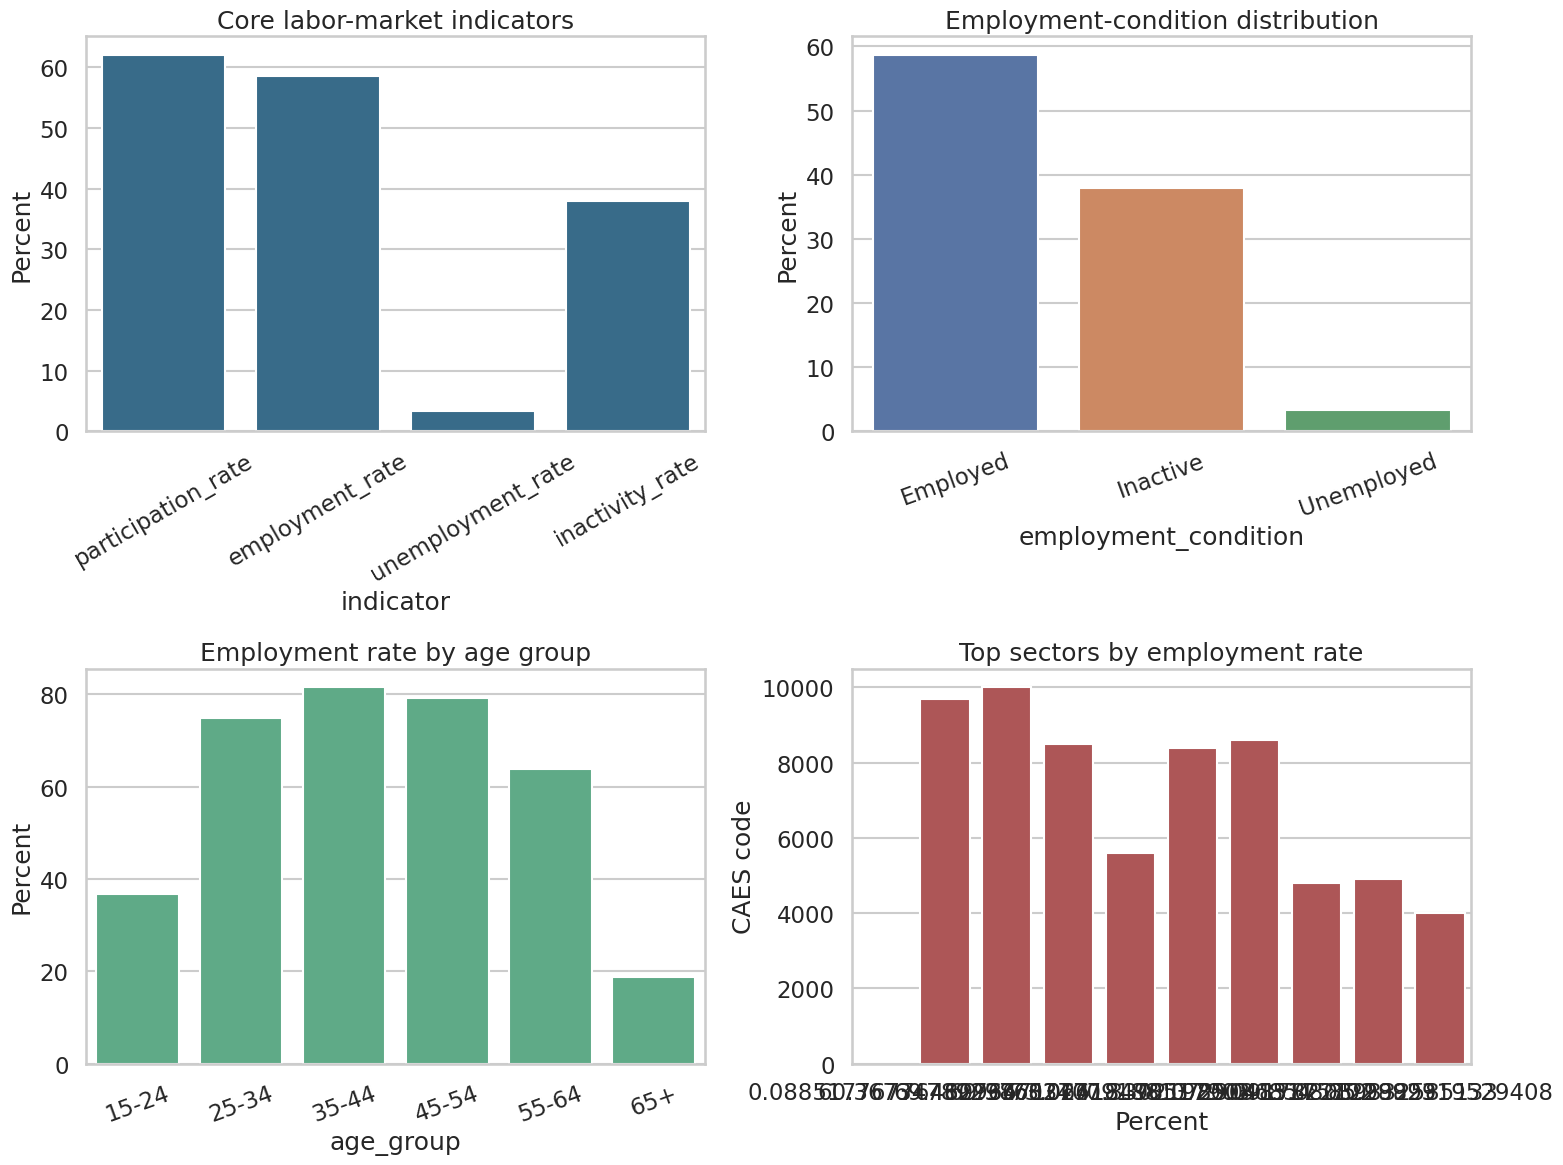

{'core_indicators':             indicator     value  value_pct
 0  participation_rate  0.620216      62.02
 1     employment_rate  0.586332      58.63
 2   unemployment_rate  0.033884       3.39
 3     inactivity_rate  0.379784      37.98,
 'status_summary':   employment_condition  weighted_count  share_pct
 0             Employed      16493425.0      58.63
 1             Inactive      10683268.0      37.98
 2           Unemployed        953156.0       3.39,
 'demographic_summary':             sex  employed  unemployed  informal_proxy  hours_main_job  labor_income
 0         Mujer  0.467054    0.041481        0.341605       10.938616   5886.709342
 1  No informado  0.513923    0.242417        0.210343        5.036872   2173.134978
 2         Varón  0.720079    0.025304        0.496575       10.864941   7933.939860,
 'sector_summary':      caes_code  weighted_employed  weighted_income  weighted_count
 143        NaN           0.000885              NaN       6097081.0
 141     9700.0    

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

core_plot = core_indicators.copy()
core_plot["value_pct"] = 100 * core_plot["value"]
sns.barplot(data=core_plot, x="indicator", y="value_pct", ax=axes[0, 0], color="#2a6f97")
axes[0, 0].set_title("Core labor-market indicators")
axes[0, 0].set_ylabel("Percent")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=status_summary, x="employment_condition", y="share_pct", ax=axes[0, 1], palette="deep")
axes[0, 1].set_title("Employment-condition distribution")
axes[0, 1].set_ylabel("Percent")
axes[0, 1].tick_params(axis="x", rotation=20)

age_plot = age_summary.copy()
age_plot["employed_pct"] = 100 * age_plot["employed"]
sns.barplot(data=age_plot, x="age_group", y="employed_pct", ax=axes[1, 0], color="#52b788")
axes[1, 0].set_title("Employment rate by age group")
axes[1, 0].set_ylabel("Percent")
axes[1, 0].tick_params(axis="x", rotation=20)

sector_plot = sector_summary.head(10).copy()
sector_plot["weighted_employed_pct"] = 100 * sector_plot["weighted_employed"]
sns.barplot(data=sector_plot, y="caes_code", x="weighted_employed_pct", ax=axes[1, 1], color="#bc4749")
axes[1, 1].set_title("Top sectors by employment rate")
axes[1, 1].set_xlabel("Percent")
axes[1, 1].set_ylabel("CAES code")

plt.tight_layout()
plt.show()

summary_tables = {
    "core_indicators": core_indicators,
    "status_summary": status_summary,
    "demographic_summary": demographic_summary,
    "sector_summary": sector_summary.head(15),
}
summary_tables

## Appendix: Map alpha thresholds to persistence distance buckets

This section computes the exact six-value alpha grid used across scripts, the beta grid used to discretize alphas into integer distance buckets, and compares, for the `enes_all` `ciuo` `hidalgo` projection, the set of edges retained by the direct disparity-filter backbone at each alpha vs the edges that would appear at the corresponding integer filtration step in the persistence distance matrix. The comparison reports counts and mismatches so you can see why the two visualizations can still differ (representation differences, layout, simplicial filling vs 1-skeleton).

In [11]:
# Configure imports to use project src
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import networkx as nx
import src.graph_construction as gc

# Paths (change if your projection filename differs)
proj_path = Path("../data/graphs/enes_all/ciuo/projection_hidalgo.gexf")
print(f"Projection exists: {proj_path.exists()}")
if not proj_path.exists():
    raise FileNotFoundError(f"Projection file not found at {proj_path}. Adjust the path to your projection GEXF.")

G = nx.read_gexf(proj_path, node_type=int)
print(f"Loaded projection graph: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

# Compute disparity graph and extract per-edge alpha_min
disp_G = gc.get_disparity_graph(G)

# alpha grid used in scripts
alphas = np.logspace(-3, 0, num=6).round(3)
betas = np.logspace(-3, 0, num=6).round(3)  # same as in get_disparity_distance_matrix
print("alphas:", alphas)
print("betas:", betas)

# Helper: compute distance bucket index as in _edge_distance_from_alpha
def edge_distance_from_alpha(alpha_min, betas_arr):
    k_max = len(betas_arr) - 1
    k = int(np.searchsorted(betas_arr, float(alpha_min), side="right"))
    return min(k, k_max)

# Gather per-edge alpha_min and distance bucket
edge_alpha = {}
edge_bucket = {}
for u, v in G.edges():
    a_uv = float(disp_G.edges[u, v].get("alpha", 1.0))
    a_vu = float(disp_G.edges[v, u].get("alpha", 1.0))
    alpha_min = min(a_uv, a_vu)
    # Normalize edge key for undirected comparisons
    edge_key = tuple(sorted((int(u), int(v))))
    edge_alpha[edge_key] = alpha_min
    edge_bucket[edge_key] = edge_distance_from_alpha(alpha_min, betas)

Projection exists: True
Loaded projection graph: nodes=472, edges=33549
alphas: [0.001 0.004 0.016 0.063 0.251 1.   ]
betas: [0.001 0.004 0.016 0.063 0.251 1.   ]


In [12]:
# Build distance-matrix-like edge sets by bucket index
from collections import defaultdict
edges_by_bucket = defaultdict(set)
for e, b in edge_bucket.items():
    edges_by_bucket[b].add(e)

# Function to compute backbone edges for given alpha via disparity_filter_backbone
def backbone_edges_at_alpha(alpha_value, keep_isolates=False):
    backbone = gc.disparity_filter_backbone(original_graph=G, disparity_graph=disp_G, alpha=float(alpha_value), mode="or", keep_isolates=keep_isolates)
    return set(tuple(sorted((int(u), int(v)))) for u, v in backbone.edges())

# Compare for each alpha from the alpha grid
results = []
for a in alphas:
    bb = backbone_edges_at_alpha(a, keep_isolates=False)
    # Determine corresponding distance-bucket cutoff used to approximate this alpha in distance-matrix filtration
    # We pick D = searchsorted(betas, a, side='right') which matches how alpha comparisons align to beta indices
    D = int(np.searchsorted(betas, float(a), side="right"))
    # Edges that would be present in persistence filtration step <= D (distance matrix values are integers)
    edges_in_persistence = set(e for e, b in edge_bucket.items() if b <= D)

    # Metrics
    intersection = bb & edges_in_persistence
    union = bb | edges_in_persistence
    jaccard = len(intersection) / len(union) if union else 1.0
    only_backbone = sorted(list(bb - edges_in_persistence))[:20]
    only_persistence = sorted(list(edges_in_persistence - bb))[:20]

    results.append({
        "alpha": float(a),
        "D_cutoff": D,
        "backbone_count": len(bb),
        "persistence_count": len(edges_in_persistence),
        "intersection_count": len(intersection),
        "jaccard": jaccard,
        "only_backbone_sample": only_backbone,
        "only_persistence_sample": only_persistence,
    })

Added 1670 edges to backbone with alpha < 0.001.
Added 2538 edges to backbone with alpha < 0.004.
Added 4024 edges to backbone with alpha < 0.016.
Added 6486 edges to backbone with alpha < 0.063.
Added 12299 edges to backbone with alpha < 0.251.
Added 67098 edges to backbone with alpha < 1.0.


In [ ]:
import pandas as pd
res_df = pd.DataFrame(results)
res_df = res_df[["alpha", "D_cutoff", "backbone_count", "persistence_count", "intersection_count", "jaccard"]]
print("Comparison table (alpha vs. persistence bucket cutoff):")
display(res_df)

# Show a couple of example mismatches to inspect why they differ
print("\nExample mismatches (up to 20 per alpha):")
for row in results:
    if row["only_backbone_sample"] or row["only_persistence_sample"]:
        print(f"\nalpha={row['alpha']}, D={row['D_cutoff']}: backbone_only({len(row['only_backbone_sample'])}), persistence_only({len(row['only_persistence_sample'])})")
        print("backbone_only sample:", row["only_backbone_sample"])
        print("persistence_only sample:", row["only_persistence_sample"])

Comparison table (alpha vs. persistence bucket cutoff):


,alpha,D_cutoff,backbone_count,persistence_count,intersection_count,jaccard
0,0.001,1,1209,1798,1209,0.672414
1,0.004,2,1798,2766,1798,0.650036
2,0.016,3,2766,4297,2766,0.643705
3,0.063,4,4297,7818,4297,0.549629
4,0.251,5,7818,33549,7818,0.233032
5,1.000,6,33549,33549,33549,1.000000



Example mismatches (up to 20 per alpha):

alpha=0.001, D=1: backbone_only(0), persistence_only(20)
backbone_only sample: []
persistence_only sample: [(10110, 10210), (10110, 13251), (10110, 15412), (10110, 15413), (10210, 13342), (10210, 13355), (11111, 12153), (11111, 12421), (11111, 13132), (11111, 13300), (11111, 13512), (11112, 12432), (11112, 12512), (11112, 12619), (11112, 12630), (11112, 13257), (11112, 13340), (11112, 13341), (11112, 13342), (11112, 13355)]

alpha=0.004, D=2: backbone_only(0), persistence_only(20)
backbone_only sample: []
persistence_only sample: [(10110, 13342), (10110, 13355), (10210, 10310), (10210, 12113), (10210, 13251), (10310, 13355), (10310, 15414), (11111, 12132), (11111, 12432), (11111, 12600), (11111, 12622), (11111, 12641), (11111, 13142), (11111, 13351), (11111, 13352), (11111, 13353), (11111, 14411), (11111, 15163), (11111, 18343), (11111, 19129)]

alpha=0.016, D=3: backbone_only(0), persistence_only(20)
backbone_only sample: []
persistence_only 